In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
# Q1: Load the data for the United States
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df = pd.read_csv(url)
df['Country/Region'] = df['Country/Region'].str.strip().str.lower()
df = df.drop(columns=['Province/State', 'Lat', 'Long']).dropna()
df_us = df[df['Country/Region'] == 'us']

In [3]:
# Process the data to get daily cases
us = df_us.sum().reset_index().iloc[1:]
us.columns = ['Date', 'Cumulative_Cases']
us['Date'] = pd.to_datetime(us['Date'])
us['Daily_Cases'] = us['Cumulative_Cases'].diff().fillna(0)

C:\Users\49498\AppData\Local\Temp\ipykernel_6372\569203641.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  us['Date'] = pd.to_datetime(us['Date'])
C:\Users\49498\AppData\Local\Temp\ipykernel_6372\569203641.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  us['Daily_Cases'] = us['Cumulative_Cases'].diff().fillna(0)


In [4]:
# Create cases sequence columns
first_case_date = us[us['Daily_Cases'] > 0].index[0]
us['Y(t)'] = us.index - first_case_date
for i in range(1, 6):
    us[f'Y(t-{i})'] = us['Daily_Cases'].shift(i)
us_lag = us.copy().dropna()

In [5]:
# Fit the OLS model
x = sm.add_constant(us_lag[['Y(t-1)', 'Y(t-2)', 'Y(t-3)', 'Y(t-4)', 'Y(t-5)']])
y = us_lag['Daily_Cases']
model = sm.OLS(y, x).fit()
params = model.params
equation = f"Y(t) = {params['const']:.2f}"
for i in range(1, 6):
    equation += f" + {params[f'Y(t-{i})']:.4f}*Y(t-{i})"
print(equation)
print(model.summary())

Y(t) = 6393.36 + 0.5184*Y(t-1) + -0.0104*Y(t-2) + 0.2197*Y(t-3) + 0.0988*Y(t-4) + 0.1043*Y(t-5)
                            OLS Regression Results                            
Dep. Variable:            Daily_Cases   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     655.4
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:19:56   Log-Likelihood:                -14211.
No. Observations:                1138   AIC:                         2.843e+04
Df Residuals:                    1132   BIC:                         2.847e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

The regression result is $$\hat{Y}_t = 6393.36 + 0.5184Y_{t-1} - 0.0104Y_{t-2} + 0.2197Y_{t-3} + 0.0988Y_{t-4} + 0.1043Y_{t-5}$$
that is, the coeffeients are $$b_0=6393.36$$ $$b_1=0.5184$$ $$b_2=-0.0104$$ $$b_3=0.2197$$ $$b_4=0.0988$$ $$b_5=0.1043$$

$b_0$ (intercept) represents the baseline number of predicted daily new cases should be 6393.36 if the daily cases were all exactly zero in past 5 days

$b_1$ to $b_5$ represent the extent to which the daily new cases today (t=0) were influenced by the daily cases in the past 5 days. For example. $b_1 = 0.5184$ means if there was one new case yesterday, the predicted new cases today will be 0.5184 more than the baseline number

Obviously, by comparing just a few rows of data, it can be found that the error of the predicted value is very large. This is because in reality, the reproduction of the virus is not linear but logistic, and the spread of the virus among the population is even more complex. Therefore, the error of simply fitting with linear regression is very large.

Mean Squared Error: 4116667733.383954


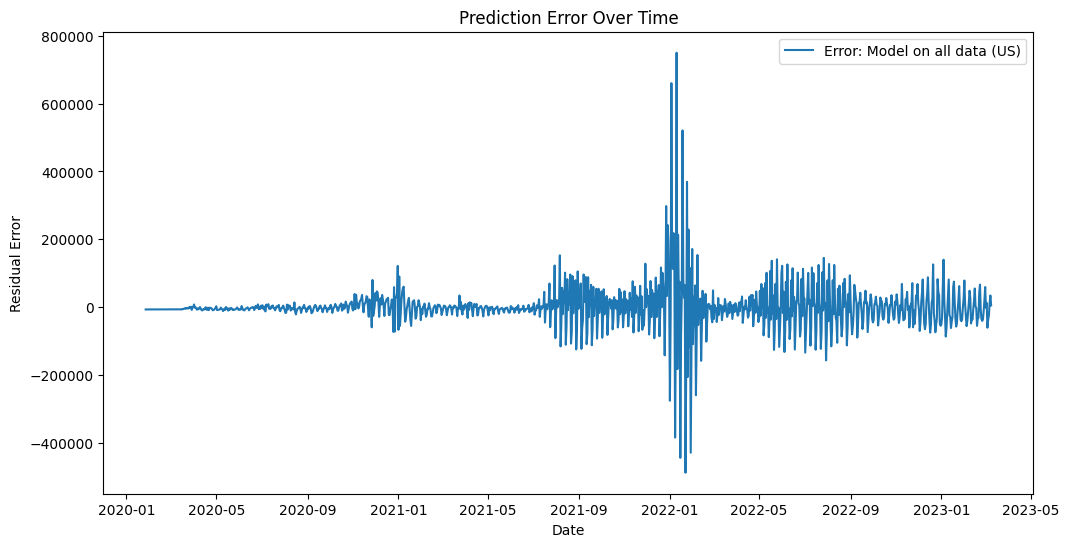

In [6]:
# Q2.1: Prediction Error over time of the model on all of the country A (US) data
pred = model.predict(x)
error = y - pred
mse = np.mean(error**2)
print('Mean Squared Error:', mse)
plt.figure(figsize=(12, 6))
plt.plot(us_lag['Date'], error, label=f'Error: Model on all data (US)')
plt.title('Prediction Error Over Time')
plt.xlabel('Date')
plt.ylabel('Residual Error')
plt.legend()
plt.show()

Mean Squared Error (Model on first half): 8025909473.592604


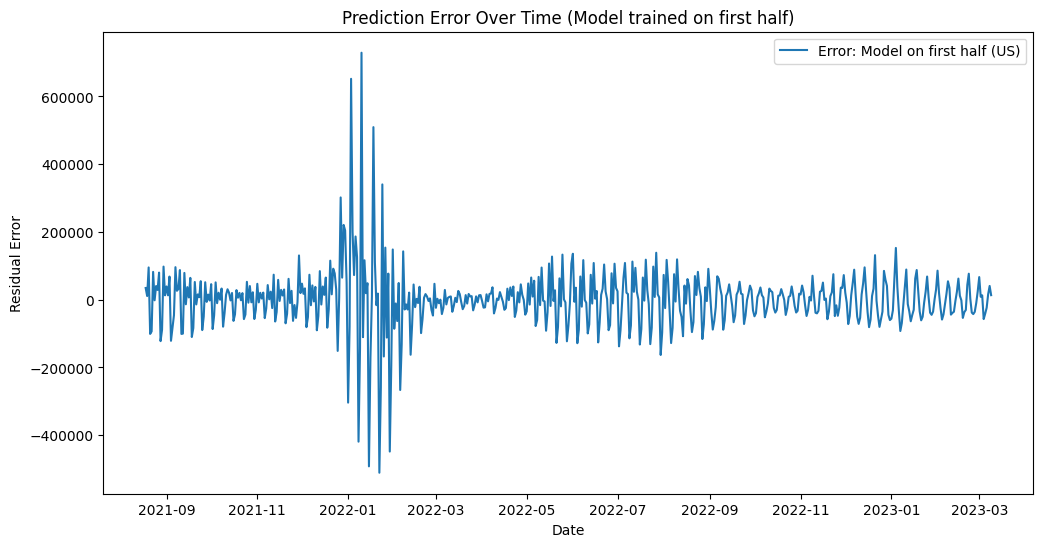

In [7]:
# Q2.2: Prediction Error over time of the model on the first half of the country A (US) data
total_length = len(us_lag)
half_length = total_length // 2
# split the dataset
x_train = sm.add_constant(us_lag.iloc[:half_length][['Y(t-1)', 'Y(t-2)', 'Y(t-3)', 'Y(t-4)', 'Y(t-5)']])
y_train = us_lag.iloc[:half_length]['Daily_Cases']
x_test = sm.add_constant(us_lag.iloc[half_length:][['Y(t-1)', 'Y(t-2)', 'Y(t-3)', 'Y(t-4)', 'Y(t-5)']])
y_test = us_lag.iloc[half_length:]['Daily_Cases']
# fit the model on the first half and calculate the error on the second half
model_half = sm.OLS(y_train, x_train).fit()
pred_half = model_half.predict(x_test)
error_half = y_test - pred_half
mse_half = np.mean(error_half**2)
print('Mean Squared Error (Model on first half):', mse_half)
# Plot the error over time for the second half of the data
plt.figure(figsize=(12, 6))
plt.plot(us_lag.iloc[half_length:]['Date'], error_half, label=f'Error: Model on first half (US)')
plt.title('Prediction Error Over Time (Model trained on first half)')
plt.xlabel('Date')
plt.ylabel('Residual Error')
plt.legend()
plt.show()

In [8]:
# Q3: Fit the model on country A (US) data and apply to country B (China) data
# Load China data
df_china = df[df['Country/Region'] == 'china']
china = df_china.sum().reset_index().iloc[1:]
china.columns = ['Date', 'Cumulative_Cases']
china['Date'] = pd.to_datetime(china['Date'])
china['Daily_Cases'] = china['Cumulative_Cases'].diff().fillna(0)
# Create cases sequence columns for China
first_case_date_china = china[china['Daily_Cases'] > 0].index[0]
china['Y(t)'] = china.index - first_case_date_china
for i in range(1, 6):
    china[f'Y(t-{i})'] = china['Daily_Cases'].shift(i)
china_lag = china.copy().dropna()

C:\Users\49498\AppData\Local\Temp\ipykernel_6372\3122827169.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  china['Date'] = pd.to_datetime(china['Date'])
C:\Users\49498\AppData\Local\Temp\ipykernel_6372\3122827169.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  china['Daily_Cases'] = china['Cumulative_Cases'].diff().fillna(0)


Mean Squared Error (Model on US applied to China): 58255241.86102208


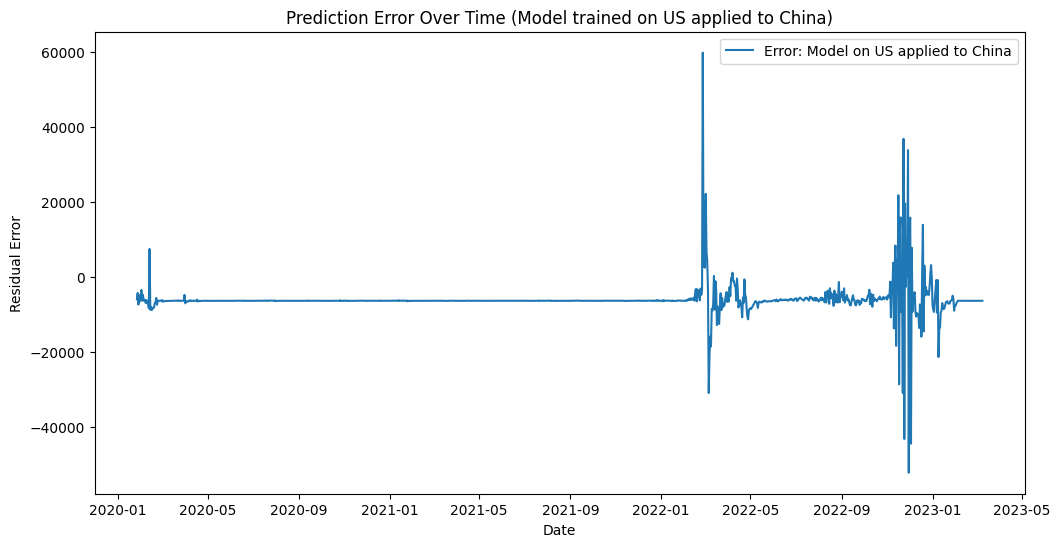

In [9]:
# Apply model on US data to China data
x_china = sm.add_constant(china_lag[['Y(t-1)', 'Y(t-2)', 'Y(t-3)', 'Y(t-4)', 'Y(t-5)']])
y_china = china_lag['Daily_Cases']
pred_china = model.predict(x_china)
error_china = y_china - pred_china
mse_china = np.mean(error_china**2)
print('Mean Squared Error (Model on US applied to China):', mse_china)
# Plot the error over time for China data
plt.figure(figsize=(12, 6))
plt.plot(china_lag['Date'], error_china, label=f'Error: Model on US applied to China')
plt.title('Prediction Error Over Time (Model trained on US applied to China)')
plt.xlabel('Date')
plt.ylabel('Residual Error')
plt.legend()
plt.show()

In [10]:
# Q4: Fit the Markov model on US data
us['Z(t)'] = (us['Daily_Cases'] > us['Daily_Cases'].shift(1)).astype(int)
for i in range(1, 6):
    us[f'Z(t-{i})'] = us['Z(t)'].shift(i)
us_markov = us.copy().dropna()
x_markov = sm.add_constant(us_markov[['Z(t-1)', 'Z(t-2)', 'Z(t-3)', 'Z(t-4)', 'Z(t-5)']])
y_markov = us_markov['Z(t)']
model_markov = sm.Logit(y_markov, x_markov).fit()
print(model_markov.summary())

Optimization terminated successfully.
         Current function value: 0.646381
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   Z(t)   No. Observations:                 1138
Model:                          Logit   Df Residuals:                     1132
Method:                           MLE   Df Model:                            5
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                 0.06737
Time:                        10:19:57   Log-Likelihood:                -735.58
converged:                       True   LL-Null:                       -788.72
Covariance Type:            nonrobust   LLR p-value:                 2.516e-21
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3343      0.187      7.135      0.000       0.968       1.701
Z(t-1)        -0.5068      0.

As the summary, the logit model is $$ Logit(P(Z_t=1)) = 1.3343 - 0.5068Z{t-1} - 0.1688Z_{t-2} - 0.8333Z_{t-3} - 1.0309Z_{t-4} - 0.2180Z_{t-5}$$
that is, the coeffeients are $$b_0=1.3343$$ $$b_1=-0.5068$$ $$b_2=-0.1688$$ $$b_3=-0.8333$$ $$b_4=-1.0309$$ $$b_5=-0.2180$$

$b_0$ means that if the number of new cases in the past 5 days all has been decreasing (Z = 0), the baseline probability of an increase in the number of new cases today is $$P(Z_t=1) = \frac{1}{1+e^{-1.3343}} = 0.79$$

$b_1$ to $b_5$ are all negative, indicating that any increase in new cases on any one of the past 5 days will reduce the predicted probability of an increase in new cases today. And it was most affected by the increase in new cases in the 4 days ago.

If new cases increased in all of the previous five days (Z = 1), the predicted probability of an increase in new cases today would only be $$P(Z_t=1) = \frac{1}{1+e^{-(1.3343-0.5068-0.1688-0.8333-1.0309-0.2180)}} = 0.19$$

The results of the Markov model may indicate that within a short period of time, such as 5 days, the virus's ability to cause new cases is relatively stable. And due to the lag in case reporting, the increase in cases in the previous days leading to a decrease in new cases today makes sense.